## Volcanoplot

Differential expression analyses frequently require a volcanoplot showing significance against fold-changes in order to pick out regulated features. Importantly, a volcanoplot is not so much a standalone kind of plot but a collection of several basic plotting elements, combined into a visual "mini-analysis" to identify significantly regulated hits. `alphapepttools.pl.volcano` summarizes several basic building blocks to abstract the following functionalities:

- scatterplot
- adding lines to the scatterplot
- adding anchored labels to the scatterplot
- adding axis labels (this is debatable, maybe we could keep this external)
- adding a legend
- setting plot x/y limits

In [ ]:
%load_ext autoreload
%autoreload 2

import pandas as pd
import numpy as np

from alphapepttools.pl import Plots
from alphapepttools.pl.colors import BaseColors

The autoreload extension is already loaded. To reload it, use:
  %reload_ext autoreload


### Generate a small example dataset

We generate a small example dataset meant to resemble a typical differential expression outcome. 

In [ ]:
# Set up reproducible random number generation
rng = np.random.default_rng(seed=42)

# example data, should be replaced by actual differential expression results from example file
testx = rng.normal(0, 1, 300)
testy = -np.cos(testx) + rng.normal(0, 0.2, 300)
testp = 10 ** -(testy - min(testy))
vp_data = pd.DataFrame(
    {
        "id": [f"P{10000 + i}" for i in range(300)],
        "gene": [f"gene_{i}" for i in range(300)],
        "log2fc": testx,
        "pval": testp,
        "neg_log10pval": -np.log10(testp),
    }
)
vp_data.index = vp_data["id"].astype(str)

# Simulate differential expression annotation
vp_data["diff_exp_status"] = vp_data["log2fc"].apply(
    lambda x: "upregulated" if x > 1 else ("downregulated" if x < -1 else "unchanged")
)

# Suppose the first 10 genes are proteins of interest
vp_data["label"] = "other"
vp_data.loc[vp_data.index[:10], "label"] = "POI"

## Basic volcanoplot

At its core, the `volcano()` function is a convenience wrapper around `scatter()`, with a special focus on layered data annotation. This is obvious when we can call the function with the bare minimum of parameters next to the basic scatterplot:

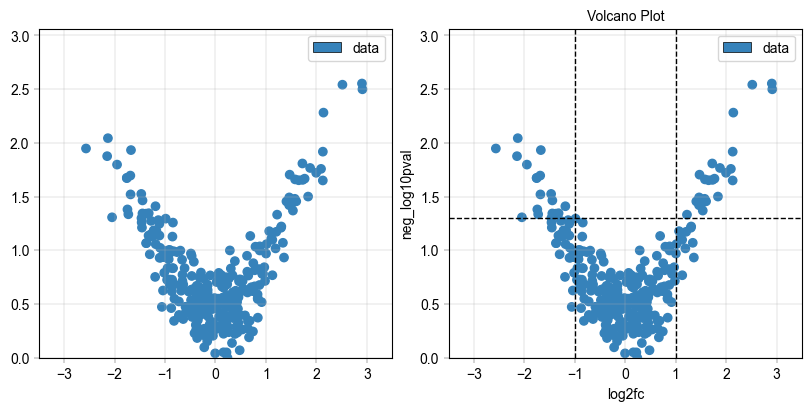

In [ ]:
from alphapepttools import pl

# As usual, we start with a figure and an axis manager that allows us to easily traverse subplots
fig, axm = pl.create_figure(1, 2, figsize=(8, 4))

# Scatterplot
Plots.scatter(
    ax=axm.next(),
    data=vp_data,
    x_column="log2fc",
    y_column="neg_log10pval",
    default_group="data",
    legend="auto",
)

# Volcanoplot, with some defaults for title, lines and labels
Plots.volcano(
    ax=axm.next(),
    data=vp_data,
    x_column="log2fc",
    y_column="neg_log10pval",
    default_group="data",
    legend="auto",
)

## Advanced layering in a volcanoplot

A particular consideration for volcanoplots is the differential coloring of various points of interest,
e.g. significantly regulated, manually selected or belonging to a certain group of interest. The current
solution uses `plot_layers` to define the hierarchy of visualization layers. `plot_layers` is a list of
tuples, where each tuple contains

layer_column, layer_val, color_key

- a `layer_column` from `data`
- a `layer_val` to match in the `layer_column`, either a single value or a list of values
- a `color_key` to retrieve a color from the `color_dict`

For example, given this plot_layers definition:

```
pois = ["P10291", "P10292", "P10293", "P10294", "P10295"]
plot_layers = [
    # look for all points in the "id" column that are in the pois list and color them according to the "POI_hypothesis" color in the color_dict
    ("id", pois, "POI_hypothesis_color"),
    # look for all points that have "POI" in the "label" column and color them according to the "POI" color in the color_dict
    ("label", "POI", "POI_color"),  # in the second layer, plot all points where the label is "POI"
    # similar for regulation status
    ("diff_exp_status", "upregulated", "upregulated_color"),
    ("diff_exp_status", "downregulated", "downregulated_color"),
    ("diff_exp_status", "unchanged", "unchanged_color"),
]
```

Importantly, order matters: these plot_layers ensure that the 'pois' are on top, then the points labeled as 'POI',
then the upregulated, downregulated and unchanged points in the background. We specify the colors in a 
separate `color_dict`, where the order of keys does not matter:

```
color_dict = {
    "upregulated_color": BaseColors.get("orange"),  # the specific point "P10001" should be colored orange
    "downregulated_color": BaseColors.get("blue"),  # the specific point "P10002" should be colored blue
    "unchanged_color": BaseColors.get("grey"),  # points from the list ["P10002", "P10003", "P10004"] should be colored grey
    "POI_color": "black",  # points where the label is "POI" should be colored black
    "POI_hypothesis_color": BaseColors.get("purple", lighten=0.7),  # points in the pois list should be colored purple
}
```

Combined with this layer_dict:

```
label_layers = [
    "POI",  # label all points where the label is "POI"
    "POI_hypothesis",  # label all points in the pois list
]
```

We create a volcanoplot that's saying "put regulated points in the background, highlight POIs in black and special 
hypothesis POIs in purple on top. Additionally, add labels only to the first two layers."

In [ ]:
# Select some points we want to highlight, e.g. if these had some hypothesis attached
pois = ["P10291", "P10292", "P10293", "P10294", "P10295"]

plot_layers = [
    ("id", pois, "POI_hypothesis_color"),  # in the first layer, plot all points in pois list
    ("label", "POI", "POI_color"),  # in the second layer, plot all points where the label is "POI"
    ("diff_exp_status", "upregulated", "upregulated_color"),  # at the third layer
    ("diff_exp_status", "downregulated", "downregulated_color"),  # in the fourth layer
    ("diff_exp_status", "unchanged", "unchanged_color"),  # in the fifth layer
]

color_dict = {
    "upregulated_color": BaseColors.get("orange"),  # the specific point "P10001" should be colored orange
    "downregulated_color": BaseColors.get("blue"),  # the specific point "P10002" should be colored blue
    "unchanged_color": BaseColors.get(
        "grey"
    ),  # points from the list ["P10002", "P10003", "P10004"] should be colored grey
    "POI_color": "black",  # points where the label is "POI" should be colored black
    "POI_hypothesis_color": BaseColors.get("red", lighten=0.2),  # points in the pois list should be colored red
}

# Add labels to selected points: call them by their color lookup keys
label_layers = [
    "POI_color",  # label all points where the label is "POI"
    "POI_hypothesis_color",  # label all points in the pois list
]

### Generating the volcanoplot with labels

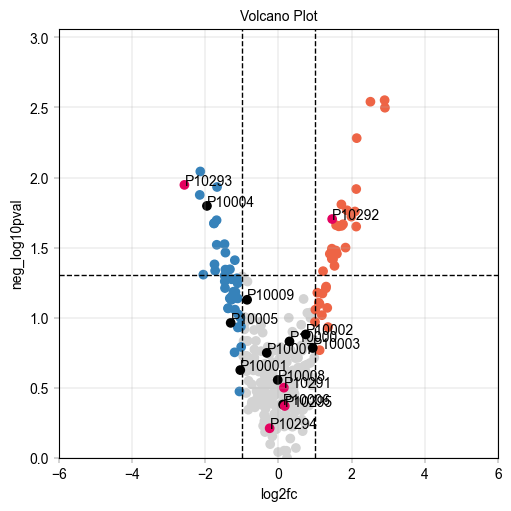

In [ ]:
Plots.volcano(
    data=vp_data,
    x_column="log2fc",
    y_column="neg_log10pval",
    color_dict=color_dict,
    plot_layers=plot_layers,
    label_layers=label_layers,
    xlims=(-6, 6),
    figure_kwargs={"figsize": (5, 5)},
)

### Direct labelling is sub-optimal...

While this achieves the plotting per se, overlapping labels are illegible and dodge/jitter solution more often than not produce scattered-looking plots that don't scale down well. We address this by resorting to _anchored stacked labels_, where we specify a number of x-axis anchors above which labels should be stacked vertically. This makes the plot much tidier, allows for clean labelling of more points and makes it very easy to scale down a plot to adapt to limited publication figure real estate

### Generate volcanoplot with anchored stacked labels

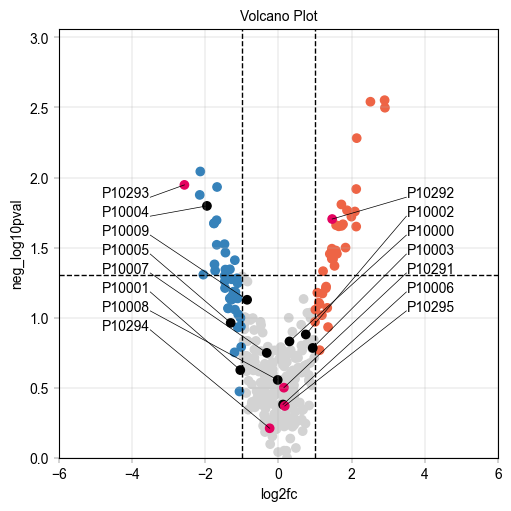

In [ ]:
Plots.volcano(
    data=vp_data,
    x_column="log2fc",
    y_column="neg_log10pval",
    color_dict=color_dict,
    plot_layers=plot_layers,
    label_layers=label_layers,
    x_label_anchors=[-3.5, 3.5],  # Put label columns in these positions (nearest points are assigned to either one)
    y_padding_factor=1.7,  # How much vertical space to add between labels
    y_display_start=0.75,  # Where to start the top label display (0 = bottom, 1 = top)
    xlims=(-6, 6),
    figure_kwargs={"figsize": (5, 5)},
)

### Scaling down the volcanoplot to fit in a single paper figure tile

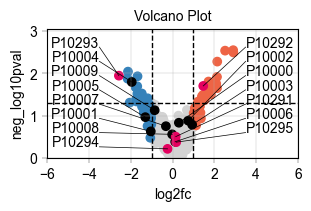

In [ ]:
Plots.volcano(
    data=vp_data,
    x_column="log2fc",
    y_column="neg_log10pval",
    color_dict=color_dict,
    plot_layers=plot_layers,
    label_layers=label_layers,
    x_label_anchors=[-3.5, 3.5],  # Put label columns in these positions (nearest points are assigned to either one)
    y_padding_factor=1.7,  # How much vertical space to add between labels
    y_display_start=1,  # Where to start the top label display (0 = bottom, 1 = top)
    xlims=(-6, 6),
    figure_kwargs={"figsize": (3, 2)},
)

### Repurposing the volcanoplot function

The `apt.pl.volcano()` function is intended for but not limited to volcanoplots. It can be repurposed to generate annotated scatterplots in general, for example highlighting points in a certain region. Consider the present example of a fictional embedding of chemical compounds.

In [ ]:
import anndata as ad
from alphapepttools.tl.embeddings import pca

rng = np.random.default_rng(seed=42)

cpd_fingerprints = rng.integers(0, 2, size=(100, 128))

compound_fingerprints = pd.DataFrame({f"compound_{i}": v for i, v in enumerate(cpd_fingerprints)})

compound_metadata = pd.DataFrame(index=compound_fingerprints.T.index)
compound_metadata["compound_id"] = compound_metadata.index
compound_metadata["property_1"] = rng.normal(0, 1, compound_metadata.shape[0])
compound_metadata["property_2"] = rng.choice(["A", "B", "C"], size=compound_metadata.shape[0])
compound_metadata.index = compound_metadata["compound_id"]

compound_adata = ad.AnnData(
    X=compound_fingerprints.T.to_numpy(),
    obs=compound_metadata,
)

# Perform PCA to get two components for plotting
pca(
    adata=compound_adata,
    dim_space="var",
    embeddings_name="PCA_2D",
    n_comps=2,
)

# extract the 2D PCA coordinates into a DataFrame for easier plotting
pca_df = pd.DataFrame(compound_adata.obsm["PCA_2D"], index=compound_metadata.index, columns=["PC1", "PC2"])
pca_adata = ad.AnnData(
    X=pca_df,
    obs=compound_metadata,
)

INFO:alphapepttools.tl.embeddings:computing PCA


Plotting the properties with a defined colordict

INFO:root:Column 'PC1' found in: data.var_names. Using that
INFO:root:Column 'PC2' found in: data.var_names. Using that
INFO:root:Column 'compound_id' found in: data.obs.columns. Using that
INFO:root:Column 'property_2' found in: data.obs.columns. Using that
INFO:root:Column 'property_2' found in: data.obs.columns. Using that
INFO:root:Column 'property_2' found in: data.obs.columns. Using that
INFO:root:Column 'PC1' found in: data.var_names. Using that
INFO:root:Column 'PC2' found in: data.var_names. Using that
INFO:root:Column 'PC1' found in: data.var_names. Using that
INFO:root:Column 'PC2' found in: data.var_names. Using that
INFO:root:Column 'PC1' found in: data.var_names. Using that
INFO:root:Column 'PC2' found in: data.var_names. Using that
INFO:root:Column 'PC1' found in: data.var_names. Using that
INFO:root:Column 'PC2' found in: data.var_names. Using that


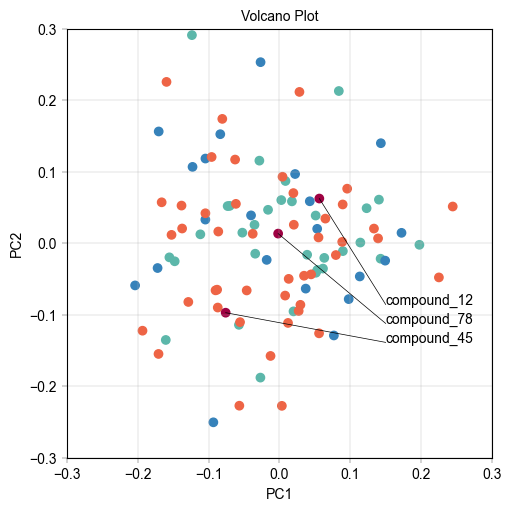

In [ ]:
special_compounds = ["compound_45", "compound_78", "compound_12"]

color_dict = {
    "property_A": BaseColors.get("orange"),
    "property_B": BaseColors.get("blue"),
    "property_C": BaseColors.get("green"),
    "special_compound": BaseColors.get("red"),
}

plot_layers = [
    ("compound_id", special_compounds, "special_compound"),
    ("property_2", "A", "property_A"),
    ("property_2", "B", "property_B"),
    ("property_2", "C", "property_C"),
]

label_layers = [
    "special_compound",
]


Plots.volcano(
    data=pca_adata,
    x_column="PC1",
    y_column="PC2",
    color_dict=color_dict,
    plot_layers=plot_layers,
    label_layers=label_layers,
    x_thresholds=None,
    y_thresholds=None,
    x_label_anchors=[0.15],  # Put label columns in these positions (nearest points are assigned to either one)
    y_padding_factor=1.7,  # How much vertical space to add between labels
    y_display_start=0.5,  # Where to start the top label display (0 = bottom, 1 = top)
    xlims=(-0.3, 0.3),
    ylims=(-0.3, 0.3),
    figure_kwargs={"figsize": (5, 5)},
)